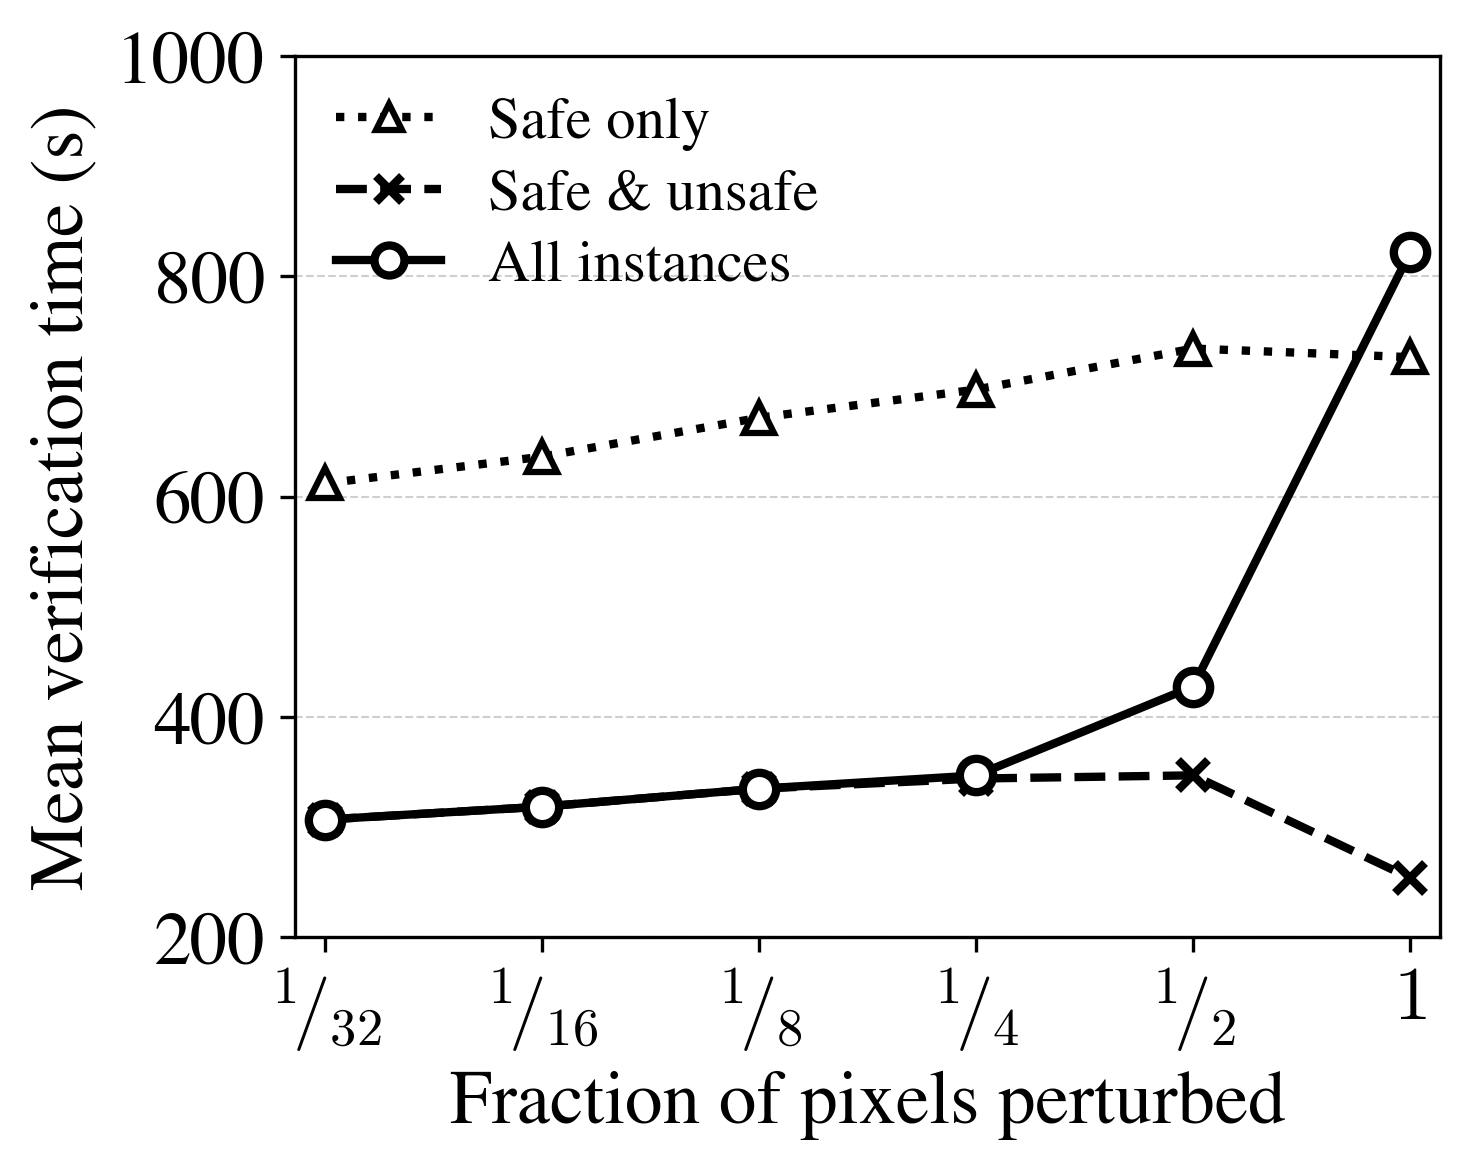

In [6]:
import numpy as np
import pandas as pd
import matplotlib as mpl
import matplotlib.pyplot as plt

# ============================
# CONFIG
# ============================
CSV_PATH = "../../results/vggnet16/all_k_vggnet16.csv"
OUT_PDF  = "Average_verification_time_paper.pdf"

# Base dataframe
df = pd.read_csv(CSV_PATH)

# numeric safety
df["k"] = pd.to_numeric(df["k"], errors="coerce")
df["all_time"] = pd.to_numeric(df["all_time"], errors="coerce")

# k values: smallest -> full image
pixel_vals = np.array([
    1568,    # 1/32
    3136,    # 1/16
    6272,    # 1/8
    12544,   # 1/4
    25088,   # 1/2
    50176,   # 1
])

# Keep only the k values of interest and non-null times
base = df[df["k"].isin(pixel_vals)].dropna(subset=["all_time"]).copy()

base = base[~base["result"].isin(["error"])].copy()

def mean_by_k(frame):
    return (
        frame.groupby("k")["all_time"]
             .mean()
             .reindex(pixel_vals)
             .values
    )

# 0) All rows
avg_time_all = mean_by_k(base)

# 1) Safe and unsafe:
# exclude timeout False and error
safe_unsafe = base[~base["result"].isin(["timeout False", "error"])].copy()
avg_time_safe_unsafe = mean_by_k(safe_unsafe)

# 2) Safe only:
# exclude timeout False, error, sat False, sat True
safe_only = base[
    ~base["result"].isin(["timeout False", "error", "sat False", "sat True"])
].copy()
avg_time_safe_only = mean_by_k(safe_only)

import matplotlib as mpl
import matplotlib.pyplot as plt

mpl.rcParams["font.family"] = "times"
mpl.rcParams["mathtext.fontset"] = "cm"

label_fs = 18
tick_fs = 18
legend_fs = 15

x_vals = np.array(pixel_vals)
x_labels = [
    r"$^{1}\!/_{32}$",
    r"$^{1}\!/_{16}$",
    r"$^{1}\!/_{8}$",
    r"$^{1}\!/_{4}$",
    r"$^{1}\!/_{2}$",
    r"$1$",
]

fig, ax = plt.subplots(figsize=(5.0, 4.0), dpi=300)

ax.set_xscale("log", base=2)
ax.set_xticks(x_vals)
ax.set_xticklabels(x_labels)
ax.set_xlim(x_vals[0] / 1.1, x_vals[-1] * 1.1)

ax.set_ylim(200, 1000)
ax.set_yticks([200, 400, 600, 800, 1000])

ax.grid(axis="y", linestyle="--", linewidth=0.5, alpha=0.6)
ax.spines["top"].set_visible(True)
ax.spines["right"].set_visible(True)

# New line 2: Safe only
ax.plot(
    x_vals,
    avg_time_safe_only,
    marker="^",
    linewidth=2,
    markersize=7,
    color="black",
    linestyle=":",
    zorder=3,
    markeredgewidth=1.5,
    markerfacecolor="white",
    label="Safe only",
)

# New line 1: Safe and unsafe
ax.plot(
    x_vals,
    avg_time_safe_unsafe,
    marker="x",
    linewidth=2,
    markersize=7,
    color="black",
    linestyle="--",
    zorder=3,
    markeredgewidth=2,
    markerfacecolor="white",
    label="Safe & unsafe",
)

# Existing line: all rows
ax.plot(
    x_vals,
    avg_time_all,
    marker="o",
    linewidth=2,
    markersize=8,
    color="black",
    markeredgewidth=2,
    markerfacecolor="white",
    markeredgecolor="black",
    zorder=3,
    label="All instances",
)

ax.set_xlabel("Fraction of pixels perturbed", fontsize=label_fs)
ax.set_ylabel("Mean verification time (s)", fontsize=label_fs)
ax.tick_params(axis="both", labelsize=tick_fs)
ax.legend(fontsize=legend_fs, frameon=False)

ax.legend(
    fontsize=14,      # text size
    frameon=False,
    handlelength=1.8, # line length in legend
    markerscale=0.9,  # marker size relative to plot marker
    labelspacing=0.3, # vertical space between entries
    borderpad=0.2,    # padding inside legend box
)

fig.tight_layout()
fig.savefig(OUT_PDF, format="pdf", bbox_inches="tight")
plt.show()
